In [ ]:
# Load the Iris dataset using pandas
import pandas as pd
df = pd.read_csv("Iris.csv")
df.info() # Display information about the dataset, including the number of entries, column names, data types, and non-null counts.

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [10]:
# Check for missing values in the dataset
df.isnull().sum() # This will display the number of missing values in each column

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [17]:
df.Species.value_counts() # This will display the count of each species in the dataset

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [18]:
# Drop the Id column — it's not a real feature
data = df.drop(columns='Id')

In [ ]:
# Separate the features (X) from the target variable (y)
X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# K-Means uses Euclidean distance, so features on larger scales would dominate. All 4 Iris features are in cm (similar range), but scaling is still best practice:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

[-0.90068117  1.03205722 -1.3412724  -1.31297673]


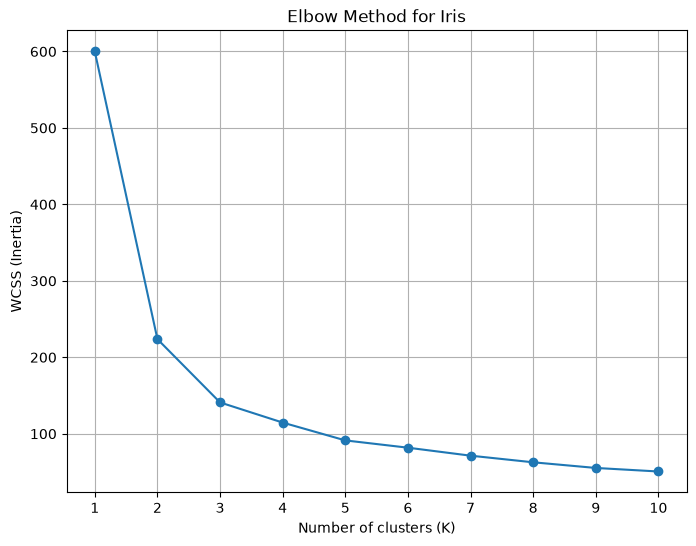

In [22]:
# Visualize the Elbow Method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Iris')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [ ]:
# Calculate silhouette scores for K=2 to K=10
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}: Silhouette = {score:.3f}")

K=2: Silhouette = 0.580
K=3: Silhouette = 0.459
K=4: Silhouette = 0.385
K=5: Silhouette = 0.347
K=6: Silhouette = 0.341
K=7: Silhouette = 0.329
K=8: Silhouette = 0.340
K=9: Silhouette = 0.343
K=10: Silhouette = 0.340


In [26]:
# Fit K-Means with the optimal number of clusters (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Centroids
print("Cluster centers (scaled):")
print(kmeans.cluster_centers_)

Cluster centers (scaled):
[[-0.05021989 -0.88029181  0.34753171  0.28206327]
 [-1.01457897  0.84230679 -1.30487835 -1.25512862]
 [ 1.13597027  0.09659843  0.996271    1.01717187]]


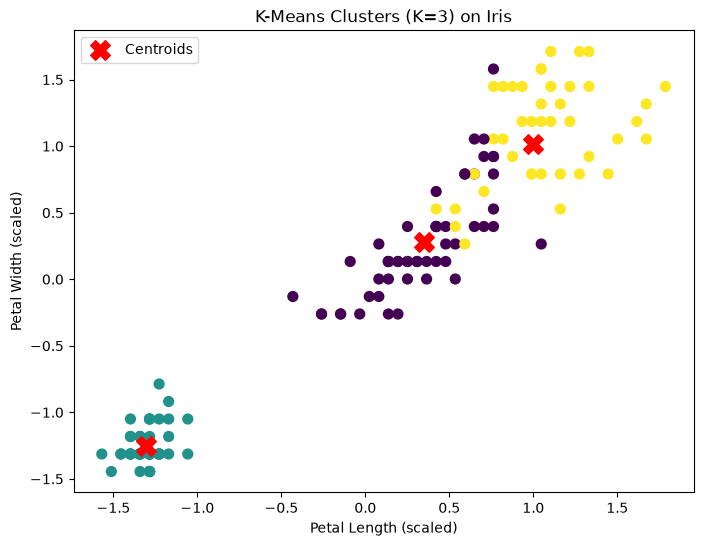

In [27]:
# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 2], X_scaled[:, 3], c=labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('K-Means Clusters (K=3) on Iris')
plt.legend()
plt.show()

In [28]:
# Cross-tabulate clusters vs true species
comparison = pd.crosstab(labels, data['Species'])
print(comparison)

Species  Iris-setosa  Iris-versicolor  Iris-virginica
row_0                                                
0                  0               39              14
1                 50                0               0
2                  0               11              36


In [29]:
# Evaluate clustering performance using silhouette score and Davies-Bouldin index
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Silhouette:", silhouette_score(X_scaled, labels))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, labels))

Silhouette: 0.4589717867018717
Davies-Bouldin: 0.8354098493935598


In [30]:
comparison = pd.crosstab(labels, data['Species'])
print(comparison)

Species  Iris-setosa  Iris-versicolor  Iris-virginica
row_0                                                
0                  0               39              14
1                 50                0               0
2                  0               11              36
